<a href="https://colab.research.google.com/github/nikasvesko/repic/blob/main/pingouin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 5.5 MB/s eta 0:00:00


In [4]:
import pingouin as pg

In [5]:
from sklearn.datasets import load_iris
iris = load_iris()

In [6]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [7]:
iris_df= pd.DataFrame(data=iris.data)

In [ ]:
iris_df

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [8]:
iris_df= pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
iris_df.tail(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3
149,5.9,3.0,5.1,1.8


In [10]:
iris_df['species']=iris.target
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
iris_df['species'].unique()

array([0, 1, 2])

In [12]:
iris_df['species'].value_counts()

,count
species,
0,50
1,50
2,50


In [13]:
species_map = {0:'setosa', 1:'versicolor', 2: 'virginica'}
iris_df['species']= iris_df['species'].map(species_map)
iris_df['species'] #dodali smo imena vrsta

,species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
145,virginica
146,virginica
147,virginica
148,virginica


In [14]:
iris_df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [15]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [16]:
iris_df.groupby('sepal length (cm)')['sepal width (cm)'].mean()

,sepal width (cm)
sepal length (cm),
4.3,3.000000
4.4,3.033333
4.5,2.300000
4.6,3.325000
4.7,3.200000
4.8,3.180000
4.9,2.950000
5.0,3.120000
5.1,3.477778


In [ ]:
iris_df.groupby('sepal length (cm)')['petal length (cm)'].std()

,petal length (cm)
sepal length (cm),
4.3,NaN
4.4,0.057735
4.5,NaN
4.6,0.221736
4.7,0.212132
4.8,0.204939
4.9,1.321615
5.0,0.834266
5.1,0.504425


In [ ]:
group_stats= iris_df.groupby('petal length (cm)').describe()
group_stats.T

petal length (cm)        1.0  1.1       1.2       1.3        1.4        1.5  \
sepal length (cm) count  1.0  1.0  2.000000  7.000000  13.000000  13.000000   
                  mean   4.6  4.3  5.400000  4.842857   4.915385   5.146154   
                  std    NaN  NaN  0.565685  0.464963   0.288231   0.275727   
                  min    4.6  4.3  5.000000  4.400000   4.400000   4.600000   
                  25%    4.6  4.3  5.200000  4.450000   4.800000   5.000000   
                  50%    4.6  4.3  5.400000  4.700000   4.900000   5.100000   
                  75%    4.6  4.3  5.600000  5.200000   5.100000   5.300000   
                  max    4.6  4.3  5.800000  5.500000   5.500000   5.700000   
sepal width (cm)  count  1.0  1.0  2.000000  7.000000  13.000000  13.000000   
                  mean   3.6  3.0  3.600000  3.228571   3.353846   3.569231   
                  std    NaN  NaN  0.565685  0.502375   0.352646   0.390266   
                  min    3.6  3.0  3.200000  2.300000   2.900000   3.100000   
                  25%    3.6  3.0  3.400000  3.100000   3.000000   3.400000   
                  50%    3.6  3.0  3.600000  3.200000   3.400000   3.500000   
                  75%    3.6  3.0  3.800000  3.500000   3.500000   3.700000   
                  max    3.6  3.0  4.000000  3.900000   4.200000   4.400000   
petal width (cm)  count  1.0  1.0  2.000000  7.000000  13.000000  13.000000   
                  mean   0.2  0.1  0.200000  0.257143   0.207692   0.238462   
                  std    NaN  NaN  0.000000  0.078680   0.064051   0.104391   
                  min    0.2  0.1  0.200000  0.200000   0.100000   0.100000   
                  25%    0.2  0.1  0.200000  0.200000   0.200000   0.200000   
                  50%    0.2  0.1  0.200000  0.200000   0.200000   0.200000   
                  75%    0.2  0.1  0.200000  0.300000   0.200000   0.300000   
                  max    0.2  0.1  0.200000  0.400000   0.300000   0.400000   

petal length (cm)             1.6       1.7       1.9  3.0  ...       5.7  \
sepal length (cm) count  7.000000  4.000000  2.000000  1.0  ...  3.000000   
                  mean   4.914286  5.400000  4.950000  5.1  ...  6.766667   
                  std    0.146385  0.244949  0.212132  NaN  ...  0.115470   
                  min    4.700000  5.100000  4.800000  5.1  ...  6.700000   
                  25%    4.800000  5.325000  4.875000  5.1  ...  6.700000   
                  50%    5.000000  5.400000  4.950000  5.1  ...  6.700000   
                  75%    5.000000  5.475000  5.025000  5.1  ...  6.800000   
                  max    5.100000  5.700000  5.100000  5.1  ...  6.900000   
sepal width (cm)  count  7.000000  4.000000  2.000000  1.0  ...  3.000000   
                  mean   3.342857  3.600000  3.600000  2.5  ...  3.266667   
                  std    0.269921  0.294392  0.282843  NaN  ...  0.057735   
                  min    3.000000  3.300000  3.400000  2.5  ...  3.200000   
                  25%    3.150000  3.375000  3.500000  2.5  ...  3.250000   
                  50%    3.400000  3.600000  3.600000  2.5  ...  3.300000   
                  75%    3.450000  3.825000  3.700000  2.5  ...  3.300000   
                  max    3.800000  3.900000  3.800000  2.5  ...  3.300000   
petal width (cm)  count  7.000000  4.000000  2.000000  1.0  ...  3.000000   
                  mean   0.285714  0.350000  0.300000  1.1  ...  2.300000   
                  std    0.157359  0.129099  0.141421  NaN  ...  0.200000   
                  min    0.200000  0.200000  0.200000  1.1  ...  2.100000   
                  25%    0.200000  0.275000  0.250000  1.1  ...  2.200000   
                  50%    0.200000  0.350000  0.300000  1.1  ...  2.300000   
                  75%    0.300000  0.425000  0.350000  1.1  ...  2.400000   
                  max    0.600000  0.500000  0.400000  1.1  ...  2.500000   

petal length (cm)             5.8       5.9       6.0       6.1  6.3  6.4  \
sepal length (cm) cou

In [ ]:
#.T transponiranje

Text(0.5, 1.0, 'cvjetovi')

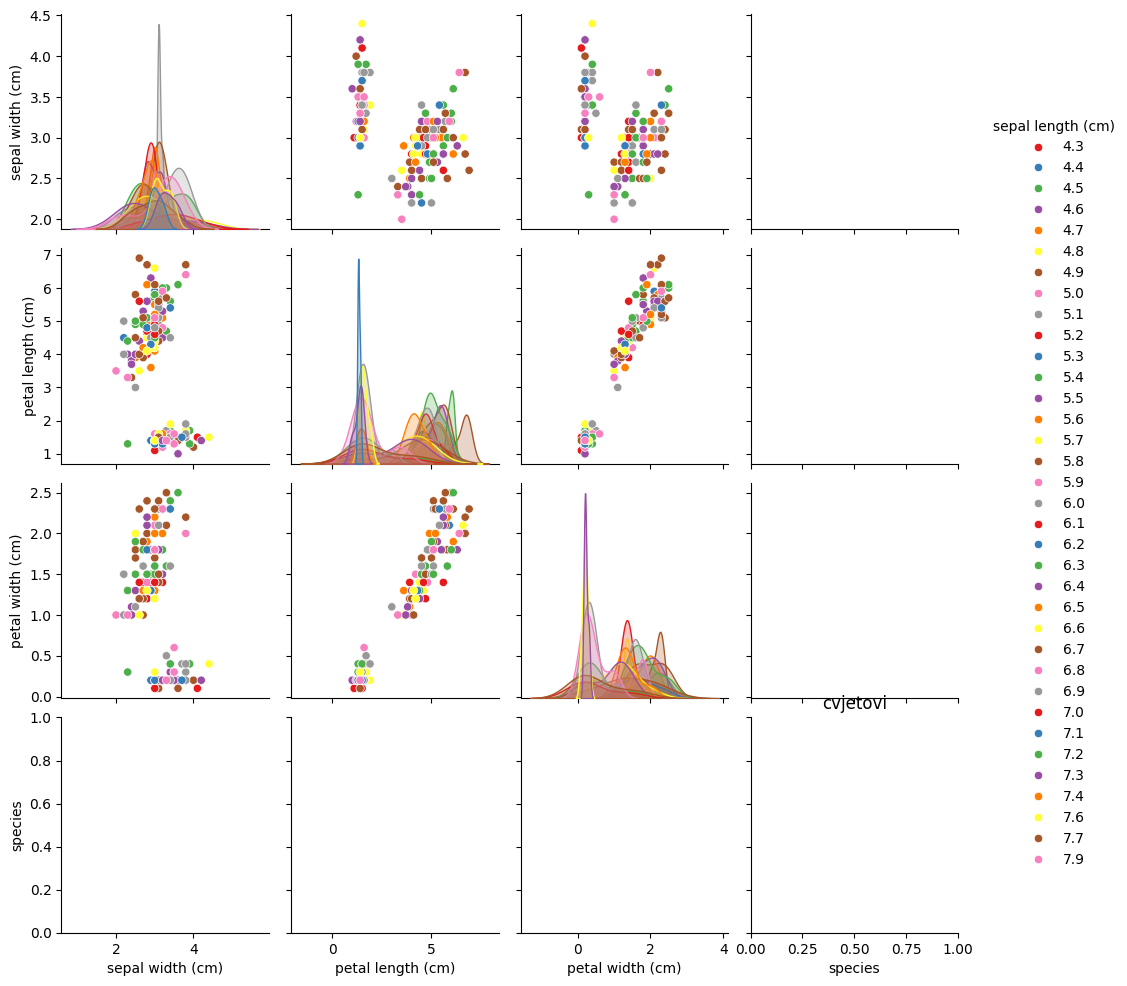

In [ ]:
#pairplot
sns.pairplot(data= iris_df, hue = 'sepal length (cm)', palette= 'Set1')
plt.title('cvjetovi')

In [ ]:
#histogrami i scatter plotovi

Text(0.5, 1.0, 'Boxplot za Iris')

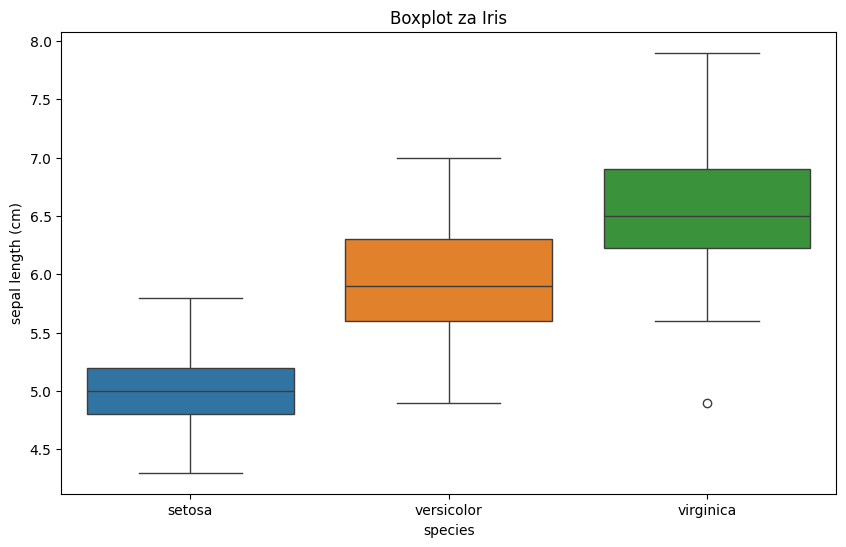

In [17]:
#boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='species', y='sepal length (cm)', data = iris_df, hue='species')
plt.title('Boxplot za Iris')

Text(0.5, 1.0, 'Boxplot za Iris')

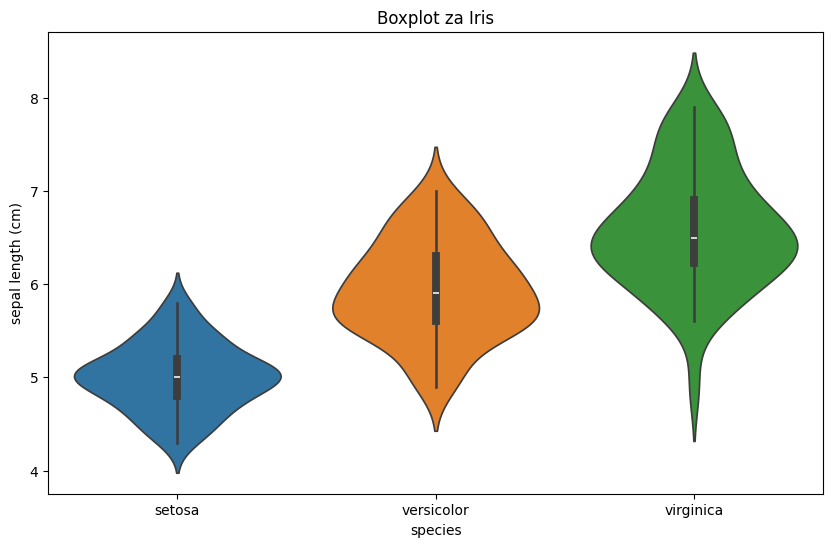

In [18]:
#violin plot
plt.figure(figsize=(10,6))
sns.violinplot(x='species', y= 'sepal length (cm)',data = iris_df, hue='species')
plt.title('Boxplot za Iris')

In [ ]:

set_versi= iris_df[iris_df['species'].isin(['setosa', 'versicolor'])]
set_versi

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species


In [ ]:
#anova
grupa1 = set_versi[set_versi['species'] == 'setosa']['sepal length (cm)']
grupa1


,sepal length (cm)


In [ ]:
grupa2= set_versi[set_versi['species']== 'versicolor']['sepal length (cm)']
grupa2

,sepal length (cm)


In [ ]:
#t test
ttest= pg.ttest(grupa1, grupa2)
print('T test rezultati (setosa vs versicolor, sepal lenght):\n', ttest)

AssertionError: y cannot be an empty list or array.

In [ ]:
sirina= pg.ttest(iris_df[iris_df['species']=='setosa']['sepal width (cm)'],
                 iris_df[iris_df['species']=='versicolor']['sepal width (cm)'])
sirina

AssertionError: y cannot be an empty list or array.

In [ ]:
#anova
anova=pg.anova(dv='sepal length (cm)', between= 'species', data=iris_df)
anova

/usr/local/lib/python3.12/dist-packages/pingouin/parametric.py:1007: RuntimeWarning: invalid value encountered in scalar divide
  mserror = sserror / ddof2
/usr/local/lib/python3.12/dist-packages/pingouin/parametric.py:1014: RuntimeWarning: invalid value encountered in scalar divide
  np2 = ssbetween / (ssbetween + sserror)  # = ssbetween / sstotal


,Source,ddof1,ddof2
0,species,-1,0


In [ ]:
#np2 je eta square, da 62% ukupne varijacije objasnjava upravo vrsta cvijeta

In [ ]:
#korelacija
corr= pg.corr(iris_df['sepal length (cm)'], iris_df['petal length (cm)'])
corr #dosta su povezani

,n,r,CI95%,p-val,BF10,power
pearson,150,0.871754,"[0.83, 0.91]",1.038667e-47,1.811e+44,1.0


In [ ]:
iris_df[['sepal length (cm)', 'petal length (cm)']].corr() #drugi nacin

,sepal length (cm),petal length (cm)
sepal length (cm),1.000000,0.871754
petal length (cm),0.871754,1.000000
